<a href="https://colab.research.google.com/github/adljna/Blu-SentimentAnalysis/blob/main/Week%204/TF-IDF/5-TFIDF-BluAppReview.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Week 4 - TF IDF Blu App Review**
This notebook continues the bag of words process previously explained in [4-BagOfWords-BluAppReview.ipynb](https://colab.research.google.com/drive/1dUq4L1RVENqTcTg5nbN7TfWcxCxRfCtv?usp=sharing)

# **(1) Import Dependencies**
This section initializes all necessary Python libraries for text processing, TF-IDF calculation, and visualization.

In [1]:
!pip install Sastrawi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 5.2 MB/s eta 0:00:00


In [7]:
import io
import nltk
from nltk.tokenize import sent_tokenize
nltk.download('punkt')
nltk.download('punkt_tab')
from sklearn.feature_extraction.text import TfidfVectorizer
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from wordcloud import WordCloud

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


# **(2) Data Load**
This section defines the blu App review that will be processed for TF-IDF based summarization.

In [8]:
from google.colab import files
uploaded = files.upload()

for fn in uploaded.keys():
    print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')

    try:
        df_bluRev = pd.read_csv(io.BytesIO(uploaded[fn]))
        print("Successfully loaded CSV into df_bluRev")

    except pd.errors.ParserError:
        print(f"Error: Could not parse {fn} as a CSV. Please upload a valid CSV file.")
        df_bluRev = pd.DataFrame()

    except Exception as e:
        print(f"An unexpected error occurred: {e}")
        df_bluRev = pd.DataFrame()

df_bluRev.head()

Saving df_bluRev_preprocessed (1).csv to df_bluRev_preprocessed (1) (1).csv
User uploaded file "df_bluRev_preprocessed (1) (1).csv" with length 12315402 bytes
Successfully loaded CSV into df_bluRev


,content,score,at,thumbsUpCount,replyContent,sentiment_label,final_content,tokens_stemmed
0,"udah lebih dr 1 mnggu, gk bisa di buka udah ga...",2,2026-03-30 09:10:30,0,"Hai, Kak Indah. Maaf atas ketidaknyamanannya. ...",negative,minggu buka ganti jaring dn ganti hp sih data ...,"['minggu', 'buka', 'ganti', 'jaring', 'dn', 'g..."
1,"bener bener kecewa sama aplikasi ini, gw kira ...",1,2026-03-30 08:05:12,0,"Hai, Kak Esa. Maaf atas ketidaknyamanannya. BC...",negative,kecewa percaya recomended kantor cabang fisik ...,"['kecewa', 'percaya', 'recomended', 'kantor', ..."
2,mantap,5,2026-03-30 08:01:13,0,"Hai, Kak Abdul. Terima kasih atas ulasannya. S...",positive,bagus,['bagus']
3,digital bank terbaik gaperlu ribet lagi pembay...,5,2026-03-30 07:38:52,0,"Hai, Kak Kenzin. Terima kasih atas ulasannya. ...",positive,baik gaperlu ribet bayar jenis apa,"['baik', 'gaperlu', 'ribet', 'bayar', 'jenis',..."
4,"aku tinggalkan blu, karena aplikasinya super l...",5,2026-03-30 07:00:00,0,"Hai, Kak Rizal. Maaf atas ketidaknyamanannya. ...",positive,tinggal aplikasi super lambat,"['tinggal', 'aplikasi', 'super', 'lambat']"


In [10]:
# Use pre-tokenized sentences from df_bluRev['final_content'], which contains cleaned sentences as strings.
if not df_bluRev.empty and 'final_content' in df_bluRev.columns:
    # Directly use the 'final_content' column as sentences
    sentence = df_bluRev['final_content'].tolist()
    print("Using preprocessed sentences from 'final_content' column of df_bluRev:")
    for sent in sentence:
        print(sent)
else:
    print("Error: df_bluRev is empty or 'final_content' column not found.")
    print("Please ensure df_bluRev is loaded correctly and contains a 'final_content' column.")
    sentence = [] # Initialize sentence as empty to prevent further errors

Using preprocessed sentences from 'final_content' column of df_bluRev:
minggu buka ganti jaring dn ganti hp sih data log error
kecewa percaya recomended kantor cabang fisik lapor by halo doang wkwkwk proses lagi
bagus
baik gaperlu ribet bayar jenis apa
tinggal aplikasi super lambat
alhamdulillah bagus terimakasih
mantappp
bagus banget userfriendly stabil aman
good
enak administrasi bulan
mudah
bantu transaksi uang tingkat
lancar mudah oke
enak transaksi pakai repot debit
nice amazing
kartu atm atm
alhamdulillah by digitall go moga slalu
bagus
cape banget dah masuk smpe gel
mudah simpel
bagus
ganggu mulu gabisa masuk
lancar jaya hambat tahan
ok
ngebantu banget
bagus
ok
bagus
lumayan gratis biaya transfer
by transaksi cepat aman god job
manfaat mudah
good and simple
mudah lumayan hemat biaya bagus up ewallet lumayan biaya
ok bagus
suka pakai transaksi uang loading masuk bayar qris transaksi tarik tunai kartu debit
ok bagus aplikasi
bantu
balikin uang respon sumpahh y transaksi tbtb bloki

# **(3) Scikit-learn TF-IDF Vectorization**

This section uses the `TfidfVectorizer` from scikit-learn to efficiently compute the TF-IDF scores for all words across all cleaned sentences. This vectorized representation is then used for the summarization process.

In [11]:
# Training TF-IDF Vectorizer on the sentences
vectorizer = TfidfVectorizer()
features = vectorizer.fit_transform(sentence)
feature_names = vectorizer.get_feature_names_out()

In [12]:
print("\nTF-IDF Feature Matrix (Sparse) on Cleaned Sentences:")
print(features)
print("\nShape of the Feature Matrix (Number of sentences, Number of unique words):")
print(features.shape)

# To see the feature names (the words in the vocabulary after Indonesian stop word removal):
feature_names = vectorizer.get_feature_names_out()
print("\nFeature Names (Words in the vocabulary):")
print(feature_names)


TF-IDF Feature Matrix (Sparse) on Cleaned Sentences:
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 142471 stored elements and shape (24968, 3464)>
  Coords	Values
  (0, 1963)	0.334167868961391
  (0, 540)	0.19035822773745076
  (0, 1013)	0.5681507441815309
  (0, 1335)	0.2546993776275376
  (0, 817)	0.38025071785646014
  (0, 1203)	0.23220063577904104
  (0, 2879)	0.22966856265288976
  (0, 717)	0.24180595634052415
  (0, 1745)	0.30924329837918496
  (0, 905)	0.24304651599394608
  (1, 1453)	0.21601768904558633
  (1, 2408)	0.2687880391993205
  (1, 2590)	0.31559431528574605
  (1, 1427)	0.2898895267275482
  (1, 571)	0.30313359234248555
  (1, 950)	0.2534400320499942
  (1, 1676)	0.2692132459689682
  (1, 566)	0.21363341173652922
  (1, 1143)	0.2714079982940614
  (1, 821)	0.2587117657312075
  (1, 3417)	0.32966605383388675
  (1, 2532)	0.19934166147586735
  (1, 1643)	0.36634126586063626
  (2, 257)	1.0
  (3, 271)	0.2786202269997519
  :	:
  (24961, 1670)	0.36186774097157043
  (24961, 3357)

# **(4) TF-IDF Analysis and Summarization**

This section details the application of `TfidfVectorizer` to compute TF-IDF scores for individual words and sentences. It includes an analysis of word-level TF-IDF scores within a sample sentence, providing a foundational understanding before proceeding to the summarization process based on sentence-level average TF-IDF scores.

In [13]:
# To see the TF-IDF values for a specific cleaned sentence (e.g., the first):
if sentence:
    first_cleaned_sentence_tfidf = features[0].toarray()
    print("\nTF-IDF values for the first sentence:")
    print(first_cleaned_sentence_tfidf)

    def get_tfidf_for_sentence(tfidf_matrix, sentence_index, feature_names):
        """Returns a DataFrame of TF-IDF values for a given sentence."""
        sentence_tfidf_values = tfidf_matrix[sentence_index].toarray().flatten()
        tfidf_df = pd.DataFrame({'Feature': feature_names, 'TF-IDF': sentence_tfidf_values})
        tfidf_df = tfidf_df[tfidf_df['TF-IDF'] > 0].sort_values(by='TF-IDF', ascending=False)
        return tfidf_df

    first_cleaned_sentence_tfidf_df = get_tfidf_for_sentence(features, 0, feature_names)
    print("\nTF-IDF values for the first cleaned sentence (sorted):")
    print(first_cleaned_sentence_tfidf_df)
else:
    print("\nNo cleaned sentences to process.")


TF-IDF values for the first sentence:
[[0. 0. 0. ... 0. 0. 0.]]

TF-IDF values for the first cleaned sentence (sorted):
     Feature    TF-IDF
1013   ganti  0.568151
817       dn  0.380251
1963  minggu  0.334168
1745     log  0.309243
1335  jaring  0.254699
905    error  0.243047
717     data  0.241806
1203      hp  0.232201
2879     sih  0.229669
540     buka  0.190358


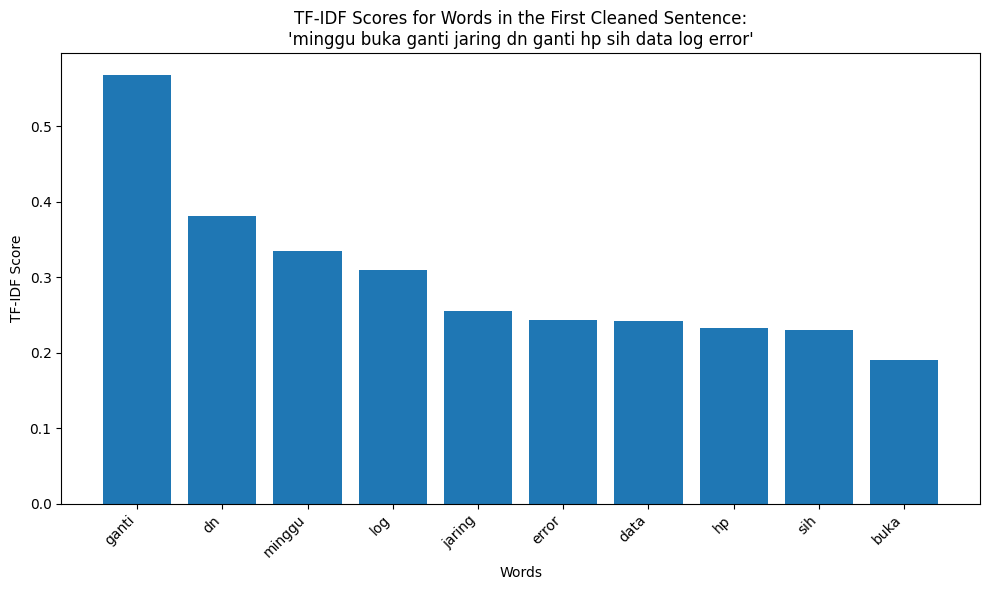

In [14]:
# Get TF-IDF scores for the first sentence
if sentence:
    first_cleaned_sentence = sentence[0]
    first_sentence_tfidf_df = get_tfidf_for_sentence(features, 0, feature_names)

    # Visualize the TF-IDF scores as a histogram
    plt.figure(figsize=(10, 6))
    plt.bar(first_sentence_tfidf_df['Feature'], first_sentence_tfidf_df['TF-IDF'])
    plt.xlabel("Words")
    plt.ylabel("TF-IDF Score")
    plt.title(f"TF-IDF Scores for Words in the First Cleaned Sentence:\n'{first_cleaned_sentence}'")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("No cleaned sentences to visualize.")

# **(5) Average TF-IDF Score Calculation and Visualization**
Here, the average TF-IDF score for each sentence is computed. Sentences with higher average scores are considered more important. A histogram visualizes these scores, and an explanation of the histogram's interpretation is provided.

In [18]:
# Variable initialization
sent_index = 0
sent_scores = []

# Calculate average TF-IDF score for each sentence with detailed output
print("\n**Calculating Average TF-IDF Score for Each Sentence:**")
for i in features:
    print(f"- Sentence {sent_index + 1}")
    sent_score = i.sum()
    sent_length = len(i.data)
    print(f"  Sum of TF-IDF scores: {sent_score:.4f}")
    print(f"  Number of words: {sent_length}")
    avg_score = sent_score / sent_length if sent_length > 0 else 0
    print(f"  Average TF-IDF score: {avg_score:.4f}")
    sent_scores.append(avg_score)
    sent_index += 1
print("\n-------------------------")

# Calculate the average of all sentence scores (threshold)
threshold = sum(sent_scores) / len(sent_scores) if sent_scores else 0

print(f"\nThreshold (Average of all Sentence Scores): {threshold:.4f}")

Streaming output truncated to the last 5000 lines.
- Sentence 23720
  Sum of TF-IDF scores: 1.3899
  Number of words: 2
  Average TF-IDF score: 0.6949
- Sentence 23721
  Sum of TF-IDF scores: 1.9294
  Number of words: 4
  Average TF-IDF score: 0.4823
- Sentence 23722
  Sum of TF-IDF scores: 1.7235
  Number of words: 3
  Average TF-IDF score: 0.5745
- Sentence 23723
  Sum of TF-IDF scores: 2.9495
  Number of words: 9
  Average TF-IDF score: 0.3277
- Sentence 23724
  Sum of TF-IDF scores: 2.4069
  Number of words: 6
  Average TF-IDF score: 0.4012
- Sentence 23725
  Sum of TF-IDF scores: 2.9621
  Number of words: 12
  Average TF-IDF score: 0.2468
- Sentence 23726
  Sum of TF-IDF scores: 1.6898
  Number of words: 3
  Average TF-IDF score: 0.5633
- Sentence 23727
  Sum of TF-IDF scores: 1.0000
  Number of words: 1
  Average TF-IDF score: 1.0000
- Sentence 23728
  Sum of TF-IDF scores: 2.4186
  Number of words: 7
  Average TF-IDF score: 0.3455
- Sentence 23729
  Sum of TF-IDF scores: 1.0000


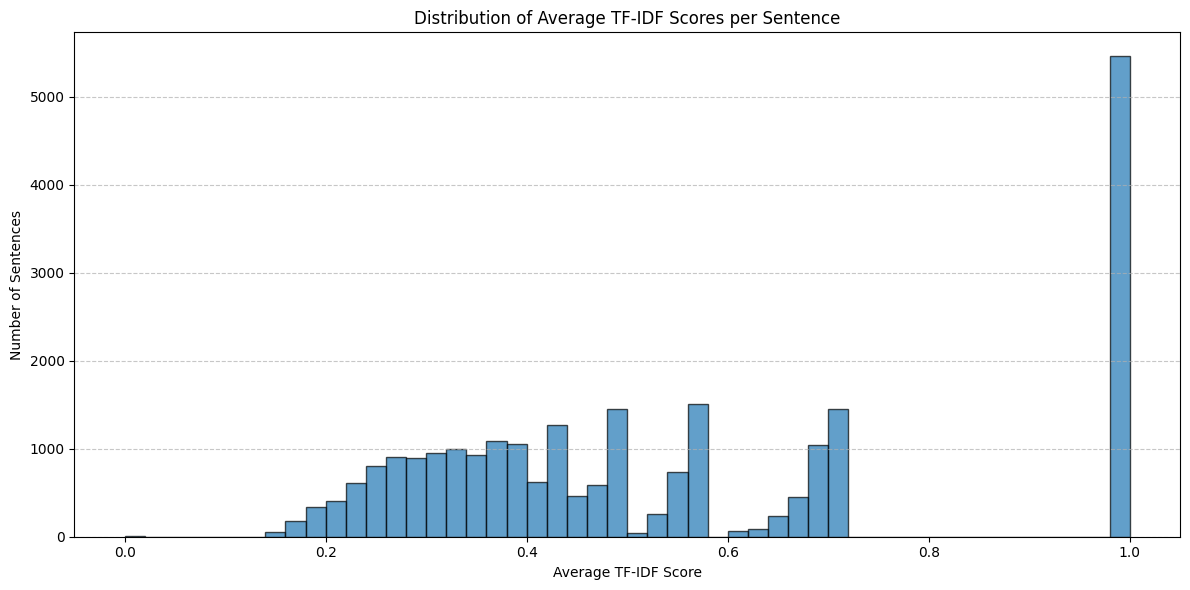


Explanation of the Histogram:
This histogram shows the distribution of average TF-IDF scores for each sentence in the document.
- Horizontal axis (Average TF-IDF Score): Represents the range of average TF-IDF score values.
- Vertical axis (Number of Sentences): Shows how many sentences have an average TF-IDF score within a specific range (or 'bin').

What can we learn from this histogram?
- Histogram peaks: The areas where the histogram is highest indicate the range of average TF-IDF scores that appear most frequently among sentences.
- Score distribution: We can see whether scores tend to cluster around certain values or are widely spread. Sentences with higher scores (to the right side of the histogram) are considered more informative or unique.
With this visualization, we can more easily understand the overall informative characteristics of the document, not just individual sentence scores.


In [37]:
# Visualize the distribution of average TF-IDF scores as a histogram
plt.figure(figsize=(12, 6))
plt.hist(sent_scores, bins=50, edgecolor='black', alpha=0.7) # Using a histogram for distribution
plt.xlabel("Average TF-IDF Score")
plt.ylabel("Number of Sentences")
plt.title("Distribution of Average TF-IDF Scores per Sentence")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Explanation:
print("\nExplanation of the Histogram:")
print("This histogram shows the distribution of average TF-IDF scores for each sentence in the document.")
print("- Horizontal axis (Average TF-IDF Score): Represents the range of average TF-IDF score values.")
print("- Vertical axis (Number of Sentences): Shows how many sentences have an average TF-IDF score within a specific range (or 'bin').")
print("\nWhat can we learn from this histogram?")
print("- Histogram peaks: The areas where the histogram is highest indicate the range of average TF-IDF scores that appear most frequently among sentences.")
print("- Score distribution: We can see whether scores tend to cluster around certain values or are widely spread. Sentences with higher scores (to the right side of the histogram) are considered more informative or unique.")
print("With this visualization, we can more easily understand the overall informative characteristics of the document, not just individual sentence scores.")

In [38]:
# Create a list of (sentence, score) tuples for sentences meeting the threshold
filtered_sentences_with_scores = []
for index, score in enumerate(sent_scores):
    if score >= threshold:
        filtered_sentences_with_scores.append((sentence[index], score))

# Sort the filtered sentences by score in descending order
sorted_sentences = sorted(filtered_sentences_with_scores, key=lambda x: x[1], reverse=True)

# Display the top 5 sentences
print("\nTop 5 Sentences Meeting the Threshold (by TF-IDF Score):")
if sorted_sentences:
    for i, (s, score) in enumerate(sorted_sentences[:5]):
        print(f"{i+1}. Score: {score:.4f} - {s}")
else:
    print("No sentences met the threshold criteria.")


Top 5 Sentences Meeting the Threshold (by TF-IDF Score):
1. Score: 1.0000 - bagus
2. Score: 1.0000 - mantappp
3. Score: 1.0000 - good
4. Score: 1.0000 - mudah
5. Score: 1.0000 - bagus


# **(6) Generated Summary**
This step filters sentences based on whether their average TF-IDF score meets or exceeds the calculated threshold, compiling them into the final summary of the document.

In [21]:
# Final summary initialization
final_summ = ""

# Get summary sentences
print("\nSummary Sentences (above or equal to the threshold):")
for index, data in enumerate(sent_scores):
    if data >= threshold:
        final_summ = final_summ + " " + sentence[index]
        print(f"- {sentence[index]}")

print("\nFinal Summary:")
print(final_summ.strip())


Summary Sentences (above or equal to the threshold):
- bagus
- mantappp
- good
- enak administrasi bulan
- mudah
- lancar mudah oke
- nice amazing
- kartu atm atm
- bagus
- mudah simpel
- bagus
- ok
- ngebantu banget
- bagus
- ok
- bagus
- manfaat mudah
- good and simple
- ok bagus
- ok bagus aplikasi
- bantu
- ok
- jos gandos
- tolong baik transaksi
- puas
- mudah promo
- blokir mana
- masuk susah banget
- puas pakai
- okeh
- enak sih pakai
- bagus banget
- muas
- bagus kendala
- bantu
- cs responsif
- ok ok
- ok banget
- bantu praktis
- mantabs
- alam gampang kena
- ok
- is the best
- bagus
- good
- ok
- bagus
- untung
- good
- coba bagus
- masuk
- awesome
- bagus
- bagus bgttttt
- alhamdulillah
- muas
- bagus
- log in cepat
- aman
- admin donk
- baik
- bagus bagus
- ok
- cepat transaksi good
- oke
- puas
- awesome
- ok bagus
- pakai bagus
- mantabbb
- mutu
- simple mudah pakai
- siiip
- buruk banget
- bantu transaksi
- bagus
- daftar cepat
- puas
- okeee
- oke
- macet
- puas
- bagu

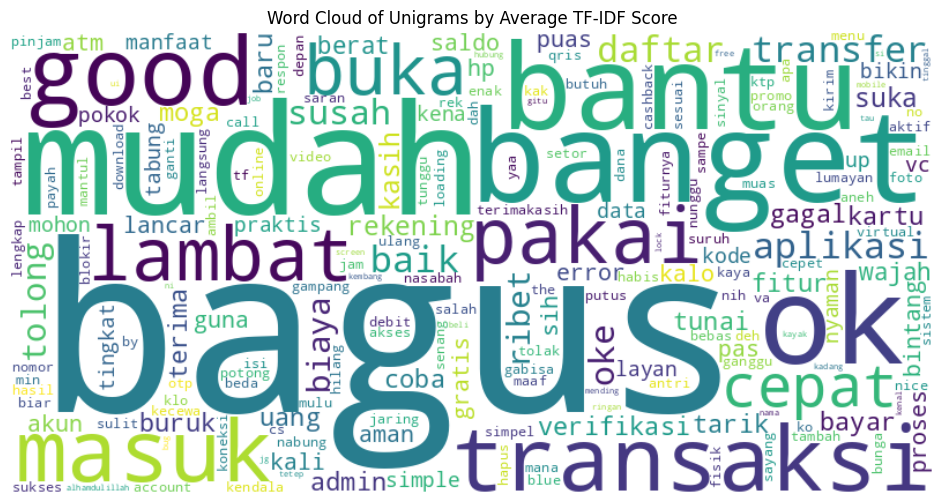

In [34]:
# Calculate average TF-IDF scores for unigrams
average_tfidf_scores_unigram = features.mean(axis=0).A1
unigram_scores_dict = dict(zip(feature_names, average_tfidf_scores_unigram))

# Generate WordCloud for Unigrams
wordcloud_unigram = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(unigram_scores_dict)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud_unigram, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Unigrams by Average TF-IDF Score')
plt.show()

# **(7) Bigram TF-IDF Analysis and Visualization**

This section performs TF-IDF vectorization specifically using bigrams (two-word sequences) to capture multi-word context. It then calculates average TF-IDF scores for each sentence, visualizes their distribution, identifies the most important bigrams, and generates a word cloud for bigrams.


TF-IDF Feature Matrix (Sparse) with Bigrams:
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 128989 stored elements and shape (24968, 68828)>
  Coords	Values
  (0, 39744)	0.3269762485354551
  (0, 11701)	0.3269762485354551
  (0, 22200)	0.30525103935082404
  (0, 27351)	0.3269762485354551
  (0, 18215)	0.3269762485354551
  (0, 22198)	0.2442606664136191
  (0, 25506)	0.3269762485354551
  (0, 56525)	0.3269762485354551
  (0, 16640)	0.3269762485354551
  (0, 36037)	0.3142678158421231
  (1, 30252)	0.2944865238454197
  (1, 48226)	0.2944865238454197
  (1, 51231)	0.2944865238454197
  (1, 29368)	0.2294880120302903
  (1, 13011)	0.2944865238454197
  (1, 20424)	0.2944865238454197
  (1, 34777)	0.283040854063148
  (1, 12822)	0.2944865238454197
  (1, 24239)	0.2944865238454197
  (1, 18330)	0.2944865238454197
  (1, 68424)	0.2944865238454197
  (1, 50079)	0.2944865238454197
  (3, 5659)	0.4687488418221114
  (3, 22294)	0.42757742614439503
  (3, 52716)	0.437603868175701
  :	:
  (24960, 40725)	0.395

,N-gram,Average TF-IDF
4867,bagus banget,0.008164
61510,terima kasih,0.005546
41163,mudah transaksi,0.004674
60701,tarik tunai,0.004468
9346,biaya admin,0.004059
11872,buka rekening,0.003696
5424,bagus up,0.003459
45026,ok banget,0.003448
62087,the best,0.003364
67467,verifikasi wajah,0.003181


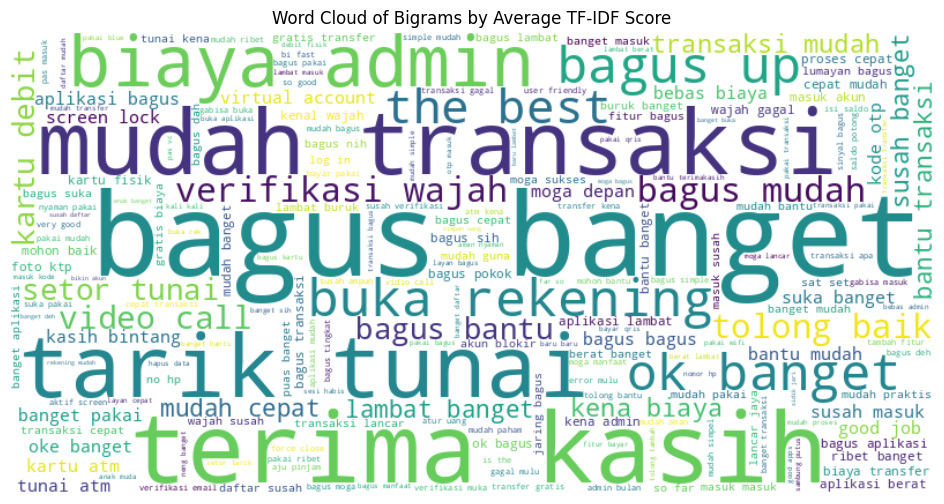

In [41]:
# Training TF-IDF Vectorizer on the sentences with Bigrams
vectorizer_bigram = TfidfVectorizer(ngram_range=(2, 2)) # Bigrams only
features_bigram = vectorizer_bigram.fit_transform(sentence)
feature_names_bigram = vectorizer_bigram.get_feature_names_out()

print("\nTF-IDF Feature Matrix (Sparse) with Bigrams:")
print(features_bigram)
print("\nShape of the Feature Matrix with Bigrams (Number of sentences, Number of unique bigrams):")
print(features_bigram.shape)

In [51]:
print("\nSample Feature Names with Bigrams (Word Pairs in the vocabulary):")
print(feature_names_bigram[:20])

# Calculate average TF-IDF scores for each bigram feature
average_tfidf_scores_bigram = features_bigram.mean(axis=0).A1
bigrams_df = pd.DataFrame({'N-gram': feature_names_bigram, 'Average TF-IDF': average_tfidf_scores_bigram})
bigrams_df = bigrams_df.sort_values(by='Average TF-IDF', ascending=False)

print("\nTop 10 Bigrams by Average TF-IDF Score:")
display(bigrams_df.head(10))


Sample Feature Names with Bigrams (Word Pairs in the vocabulary):
['aaaa best' 'aaaa mudah' 'aaaa suka' 'abad abad' 'abad gantiin' 'abad gx'
 'abal abal' 'abal ngabisin' 'abang bantu' 'abang jago' 'abang kurir'
 'abang suka' 'abis ambil' 'abis angkat' 'abis baru' 'abis batre'
 'abis bikin' 'abis bnyak' 'abis cs' 'abis daftar']

Top 10 Bigrams by Average TF-IDF Score:


,N-gram,Average TF-IDF
4867,bagus banget,0.008164
61510,terima kasih,0.005546
41163,mudah transaksi,0.004674
60701,tarik tunai,0.004468
9346,biaya admin,0.004059
11872,buka rekening,0.003696
5424,bagus up,0.003459
45026,ok banget,0.003448
62087,the best,0.003364
67467,verifikasi wajah,0.003181


In [42]:
# Variable initialization for bigram scores
sent_scores_bigram = []

# Calculate average TF-IDF score for each sentence using Bigram features
print("\n**Calculating Average TF-IDF Score for Each Sentence with Bigrams:**")
for i, features_row in enumerate(features_bigram):
    if features_row.nnz > 0:
        sent_score_bigram = features_row.sum()
        sent_length_bigram = features_row.nnz
        avg_score_bigram = sent_score_bigram / sent_length_bigram
    else:
        avg_score_bigram = 0.0

    print(f"- Sentence {i + 1}: Sum of TF-IDF (Bigram): {sent_score_bigram:.4f}, Num Bigrams: {sent_length_bigram}, Avg TF-IDF (Bigram): {avg_score_bigram:.4f}")
    sent_scores_bigram.append(avg_score_bigram)

print("\n-------------------------")

# Calculate the average of all sentence scores (threshold) for bigrams
threshold_bigram = sum(sent_scores_bigram) / len(sent_scores_bigram) if sent_scores_bigram else 0

print(f"\nThreshold (Average of all Sentence Scores with Bigrams): {threshold_bigram:.4f}")

Streaming output truncated to the last 5000 lines.
- Sentence 19973: Sum of TF-IDF (Bigram): 2.2346, Num Bigrams: 5, Avg TF-IDF (Bigram): 0.0000
- Sentence 19974: Sum of TF-IDF (Bigram): 1.9434, Num Bigrams: 4, Avg TF-IDF (Bigram): 0.4858
- Sentence 19975: Sum of TF-IDF (Bigram): 1.9434, Num Bigrams: 4, Avg TF-IDF (Bigram): 0.0000
- Sentence 19976: Sum of TF-IDF (Bigram): 1.4105, Num Bigrams: 2, Avg TF-IDF (Bigram): 0.7052
- Sentence 19977: Sum of TF-IDF (Bigram): 1.9950, Num Bigrams: 4, Avg TF-IDF (Bigram): 0.4987
- Sentence 19978: Sum of TF-IDF (Bigram): 2.1936, Num Bigrams: 5, Avg TF-IDF (Bigram): 0.4387
- Sentence 19979: Sum of TF-IDF (Bigram): 1.3967, Num Bigrams: 2, Avg TF-IDF (Bigram): 0.6983
- Sentence 19980: Sum of TF-IDF (Bigram): 4.0576, Num Bigrams: 17, Avg TF-IDF (Bigram): 0.2387
- Sentence 19981: Sum of TF-IDF (Bigram): 2.6436, Num Bigrams: 7, Avg TF-IDF (Bigram): 0.3777
- Sentence 19982: Sum of TF-IDF (Bigram): 1.9913, Num Bigrams: 4, Avg TF-IDF (Bigram): 0.4978
- Senten

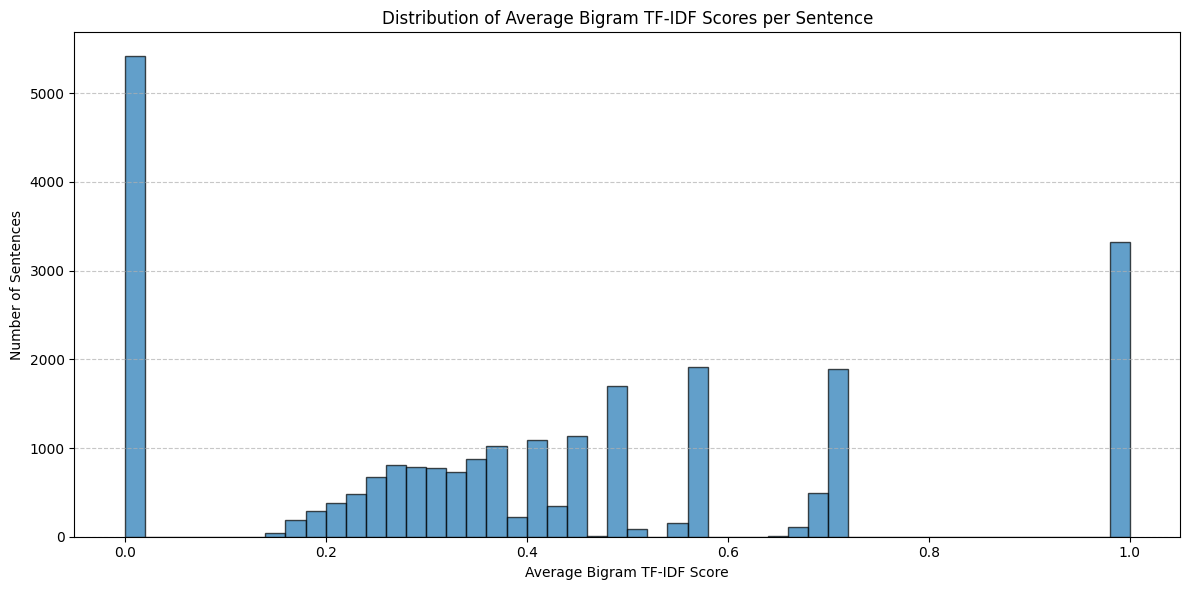


Explanation of the Histogram for Bigram TF-IDF Scores:
This histogram shows the distribution of average TF-IDF scores per sentence, considering bigrams. It provides a more detailed picture of how sentences are rated for importance when the context of word pairs is also taken into account.
Histogram peaks indicate the most common score ranges, while the spread to the right shows sentences containing more unique and contextually important word pairs.


In [43]:
# Visualize the distribution of average Bigram TF-IDF scores as a histogram
plt.figure(figsize=(12, 6))
plt.hist(sent_scores_bigram, bins=50, edgecolor='black', alpha=0.7)
plt.xlabel("Average Bigram TF-IDF Score")
plt.ylabel("Number of Sentences")
plt.title("Distribution of Average Bigram TF-IDF Scores per Sentence")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Explanation:
print("\nExplanation of the Histogram for Bigram TF-IDF Scores:")
print("This histogram shows the distribution of average TF-IDF scores per sentence, considering bigrams. It provides a more detailed picture of how sentences are rated for importance when the context of word pairs is also taken into account.")
print("Histogram peaks indicate the most common score ranges, while the spread to the right shows sentences containing more unique and contextually important word pairs.")

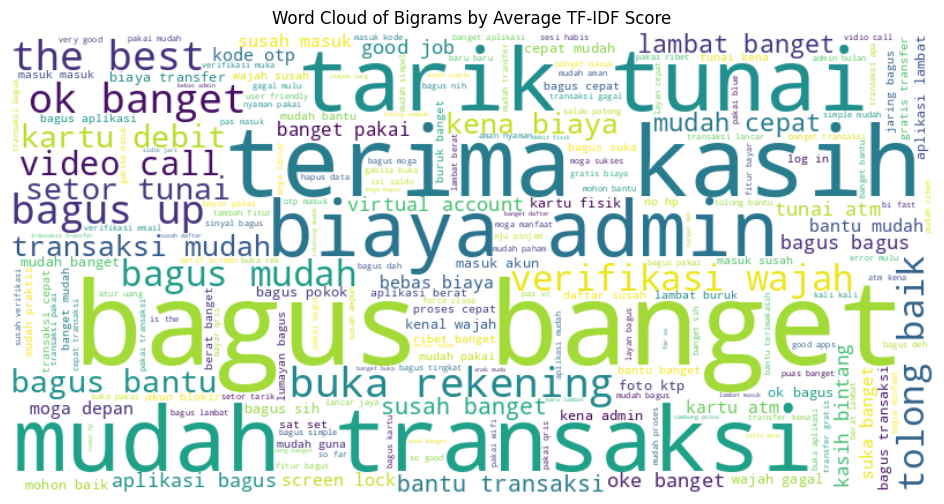

In [44]:
from wordcloud import WordCloud
# Generate WordCloud for Bigrams
bigram_scores_dict = dict(zip(bigrams_df['N-gram'], bigrams_df['Average TF-IDF']))
wordcloud_bigram = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(bigram_scores_dict)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud_bigram, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Bigrams by Average TF-IDF Score')
plt.show()

# **(8) Trigram TF-IDF Analysis and Visualization**

This section performs TF-IDF vectorization specifically using trigrams (three-word sequences) to capture more complex multi-word context. It then calculates average TF-IDF scores for each sentence, visualizes their distribution, identifies the most important trigrams, and generates a word cloud for trigrams.

In [49]:
# Training TF-IDF Vectorizer on the sentences with Trigrams
vectorizer_trigram = TfidfVectorizer(ngram_range=(3, 3)) # Trigrams only
features_trigram = vectorizer_trigram.fit_transform(sentence)
feature_names_trigram = vectorizer_trigram.get_feature_names_out()

print("\nTF-IDF Feature Matrix (Sparse) with Trigrams:")
print(features_trigram)
print("\nShape of the Feature Matrix with Trigrams (Number of sentences, Number of unique trigrams):")
print(features_trigram.shape)


TF-IDF Feature Matrix (Sparse) with Trigrams:
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 110968 stored elements and shape (24968, 99636)>
  Coords	Values
  (0, 57096)	0.3333333333333333
  (0, 18291)	0.3333333333333333
  (0, 33190)	0.3333333333333333
  (0, 39632)	0.3333333333333333
  (0, 27767)	0.3333333333333333
  (0, 33186)	0.3333333333333333
  (0, 37278)	0.3333333333333333
  (0, 80763)	0.3333333333333333
  (0, 25886)	0.3333333333333333
  (1, 43970)	0.30151134457776363
  (1, 69600)	0.30151134457776363
  (1, 73450)	0.30151134457776363
  (1, 42411)	0.30151134457776363
  (1, 20538)	0.30151134457776363
  (1, 30305)	0.30151134457776363
  (1, 50258)	0.30151134457776363
  (1, 20307)	0.30151134457776363
  (1, 35647)	0.30151134457776363
  (1, 27885)	0.30151134457776363
  (1, 99203)	0.30151134457776363
  (3, 8693)	0.5
  (3, 33329)	0.5
  (3, 75569)	0.5
  (3, 12770)	0.5
  (4, 88784)	0.7071067811865476
  :	:
  (24956, 75939)	0.408248290463863
  (24956, 86374)	0.408248290463863


In [50]:
print("\nSample Feature Names with Trigrams (Word Triples in the vocabulary):")
print(feature_names_trigram[:20])

# Calculate average TF-IDF scores for each trigram feature
average_tfidf_scores_trigram = features_trigram.mean(axis=0).A1
trigrams_df = pd.DataFrame({'N-gram': feature_names_trigram, 'Average TF-IDF': average_tfidf_scores_trigram})
trigrams_df = trigrams_df.sort_values(by='Average TF-IDF', ascending=False)

print("\nTop 10 Trigrams by Average TF-IDF Score:")
display(trigrams_df.head(10))


Sample Feature Names with Trigrams (Word Triples in the vocabulary):
['aaaa mudah sayang' 'aaaa suka bangetttt' 'abad abad gx'
 'abad gantiin dev' 'abad gx ngotak' 'abal abal ngabisin'
 'abal ngabisin quota' 'abang bantu daftar' 'abang kurir jne'
 'abang suka cocok' 'abis ambil orang' 'abis angkat no' 'abis baru baru'
 'abis baru berat' 'abis baru buka' 'abis baru buruk' 'abis baru gabisa'
 'abis baru lambat' 'abis baru log' 'abis baru pakai']

Top 10 Trigrams by Average TF-IDF Score:


,N-gram,Average TF-IDF
86572,tarik tunai atm,0.001166
44702,kena biaya admin,0.000888
13327,bebas biaya admin,0.000809
38539,is the best,0.000744
97484,verifikasi wajah gagal,0.000713
1705,aktif screen lock,0.000644
86631,tarik tunai kena,0.000636
80117,setor tunai atm,0.000617
93700,tunai kena biaya,0.000545
30038,far so good,0.000541


In [46]:
# Variable initialization for trigram scores
sent_scores_trigram = []

# Calculate average TF-IDF score for each sentence using Trigram features
print("\n**Calculating Average TF-IDF Score for Each Sentence with Trigrams:**")
for i, features_row in enumerate(features_trigram):
    if features_row.nnz > 0:
        sent_score_trigram = features_row.sum()
        sent_length_trigram = features_row.nnz
        avg_score_trigram = sent_score_trigram / sent_length_trigram
    else:
        avg_score_trigram = 0.0

    print(f"- Sentence {i + 1}: Sum of TF-IDF (Trigram): {sent_score_trigram:.4f}, Num Trigrams: {sent_length_trigram}, Avg TF-IDF (Trigram): {avg_score_trigram:.4f}")
    sent_scores_trigram.append(avg_score_trigram)

print("\n-------------------------")

# Calculate the average of all sentence scores (threshold) for trigrams
threshold_trigram = sum(sent_scores_trigram) / len(sent_scores_trigram) if sent_scores_trigram else 0

print(f"\nThreshold (Average of all Sentence Scores with Trigrams): {threshold_trigram:.4f}")

Streaming output truncated to the last 5000 lines.
- Sentence 19973: Sum of TF-IDF (Trigram): 2.0000, Num Trigrams: 4, Avg TF-IDF (Trigram): 0.0000
- Sentence 19974: Sum of TF-IDF (Trigram): 1.7305, Num Trigrams: 3, Avg TF-IDF (Trigram): 0.5768
- Sentence 19975: Sum of TF-IDF (Trigram): 1.7305, Num Trigrams: 3, Avg TF-IDF (Trigram): 0.0000
- Sentence 19976: Sum of TF-IDF (Trigram): 1.0000, Num Trigrams: 1, Avg TF-IDF (Trigram): 1.0000
- Sentence 19977: Sum of TF-IDF (Trigram): 1.7321, Num Trigrams: 3, Avg TF-IDF (Trigram): 0.5774
- Sentence 19978: Sum of TF-IDF (Trigram): 1.9997, Num Trigrams: 4, Avg TF-IDF (Trigram): 0.4999
- Sentence 19979: Sum of TF-IDF (Trigram): 1.0000, Num Trigrams: 1, Avg TF-IDF (Trigram): 1.0000
- Sentence 19980: Sum of TF-IDF (Trigram): 4.1196, Num Trigrams: 17, Avg TF-IDF (Trigram): 0.2423
- Sentence 19981: Sum of TF-IDF (Trigram): 2.4495, Num Trigrams: 6, Avg TF-IDF (Trigram): 0.4082
- Sentence 19982: Sum of TF-IDF (Trigram): 1.7321, Num Trigrams: 3, Avg TF-

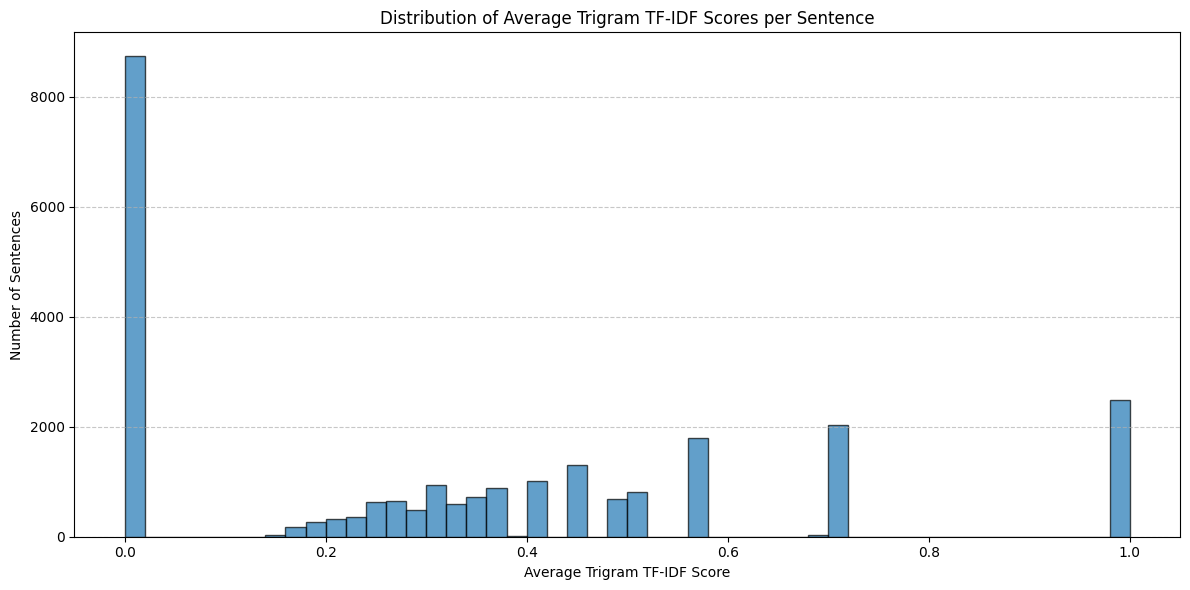


Explanation of the Histogram for Trigram TF-IDF Scores:
This histogram shows the distribution of average TF-IDF scores per sentence, considering trigrams. It provides a more detailed picture of how sentences are rated for importance when the context of three-word sequences is also taken into account.
Histogram peaks indicate the most common score ranges, while the spread to the right shows sentences containing more unique and contextually important three-word sequences.


In [47]:
# Visualize the distribution of average Trigram TF-IDF scores as a histogram
plt.figure(figsize=(12, 6))
plt.hist(sent_scores_trigram, bins=50, edgecolor='black', alpha=0.7)
plt.xlabel("Average Trigram TF-IDF Score")
plt.ylabel("Number of Sentences")
plt.title("Distribution of Average Trigram TF-IDF Scores per Sentence")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Explanation:
print("\nExplanation of the Histogram for Trigram TF-IDF Scores:")
print("This histogram shows the distribution of average TF-IDF scores per sentence, considering trigrams. It provides a more detailed picture of how sentences are rated for importance when the context of three-word sequences is also taken into account.")
print("Histogram peaks indicate the most common score ranges, while the spread to the right shows sentences containing more unique and contextually important three-word sequences.")

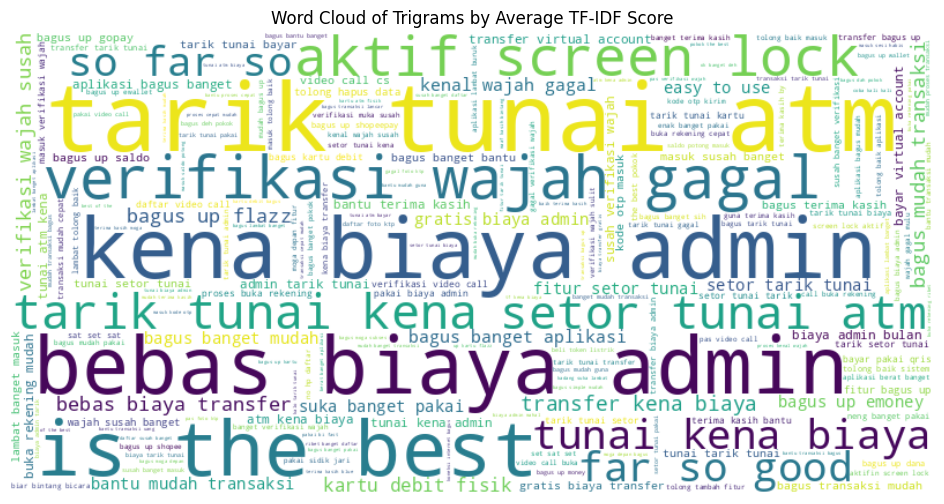

In [48]:
from wordcloud import WordCloud
# Generate WordCloud for Trigrams
trigram_scores_dict = dict(zip(trigrams_df['N-gram'], trigrams_df['Average TF-IDF']))
wordcloud_trigram = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(trigram_scores_dict)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud_trigram, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Trigrams by Average TF-IDF Score')
plt.show()